# Final Notebook: IoT Water Disaggregation (Student Version)

This notebook is prepared as a **final clean version** for students.

## What this notebook covers
1. Load one prepared dataset (`water_dissegration_data.csv`)
2. Clean and standardize labels/timestamps
3. Preprocess signal (outlier handling, smoothing, slope extraction)
4. Create window-based features
5. Train selected beginner-friendly models

## Models included
- Classical ML: Logistic Regression, KNN, SVM, Random Forest
- Deep Learning: LSTM, GRU, CNN

In [1]:
# Install required libraries (run once)
%pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
exceptiongroup 1.3.0 requires typing-extensions>=4.6.0; python_version < "3.13", but you have typing-extensions 4.5.0 which is incompatible.
fastapi 0.121.0 requires typing-extensions>=4.8.0, but you have typing-extensions 4.5.0 which is incompatible.
pydantic 2.10.6 requires typing-extensions>=4.12.2, but you have typing-extensions 4.5.0 which is incompatible.
pydantic-core 2.27.2 requires typing-extensions!=4.7.0,>=4.6.0, but you have typing-extensions 4.5.0 which is incompatible.
sqlalchemy 2.0.44 requires typing-extensions>=4.6.0, but you have typing-extensions 4.5.0 which is incompatible.


## Environment Setup (Install Dependencies)
Run this once to ensure all required packages are available in your notebook environment.

This notebook uses:
- Data handling: `pandas`, `numpy`
- Visualization: `matplotlib`, `seaborn`
- Classical ML: `scikit-learn`
- Deep Learning: `tensorflow` (Keras API)

## Step 1: Imports and Configuration
This cell prepares all core libraries and defines reproducible experiment settings.

### Library explanation (why each is used)
- `warnings`: suppresses noisy warnings so students can focus on outputs.
- `pathlib.Path`: handles dataset/model paths safely across operating systems.
- `numpy`: fast numerical arrays for feature windows and model inputs.
- `pandas`: tabular data loading, cleaning, timestamp parsing, grouping, and resampling.
- `matplotlib` and `seaborn`: plotting and confusion matrix visualization.
- `scikit-learn` (`train_test_split`, metrics, classifiers, pipeline/scaler): classical ML workflow and evaluation.
- `tensorflow.keras`: deep learning model definitions (LSTM/GRU/CNN), training loop, callbacks, and one-hot label handling.

### Reproducibility and paths
- `RANDOM_STATE = 42` is used for consistent train-test split and model behavior.
- `BASE_DIR` and `DATA_PATH` ensure this notebook reads `water_dissegration_data.csv` from the same folder.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "water_dissegration_data.csv"

print(f"Dataset path: {DATA_PATH}")
print(f"Exists: {DATA_PATH.exists()}")

Dataset path: c:\Users\sahas\Downloads\College-Research-Affiliate-Program-26-main\College-Research-Affiliate-Program-26-main\ml_model\water_dissegration_data.csv
Exists: True


## Step 2: Load and Clean Data
This step reads the CSV, standardizes class labels, parses timestamps, and ensures required columns are available.

If `source_file` is missing in the CSV, we create it so the rest of the pipeline works consistently.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

training_df = pd.read_csv(DATA_PATH)

if "source_file" not in training_df.columns:
    training_df["source_file"] = DATA_PATH.name

label_map = {
    "no activity": "no_activity",
    "no-activity": "no_activity",
    "washing machine": "washing_machine",
    "washing-machine": "washing_machine",
}

training_df["label"] = (
    training_df["label"].astype(str).str.strip().str.lower().replace(label_map)
)
training_df["Timestamp"] = pd.to_datetime(training_df["Timestamp"], errors="coerce")

required_cols = ["Timestamp", "distance", "label", "source_file"]
training_df = training_df.dropna(subset=required_cols).copy()
training_df = training_df.sort_values(["source_file", "Timestamp"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(training_df)}")
print("Class distribution:")
print(training_df["label"].value_counts())
training_df.head()

Rows after cleaning: 42028
Class distribution:
label
no_activity        23434
filling            13138
flush               2056
washing_machine     1985
geyser              1415
Name: count, dtype: int64


,Timestamp,distance,diff,slope,label,source_file
0,2024-06-08 09:00:00+05:30,86.134198,0.000000,0.0,no_activity,water_dissegration_data.csv
1,2024-06-08 09:00:10+05:30,86.098701,-0.035497,0.0,no_activity,water_dissegration_data.csv
2,2024-06-08 09:00:20+05:30,86.073425,-0.025276,0.0,no_activity,water_dissegration_data.csv
3,2024-06-08 09:00:30+05:30,86.060569,-0.012856,0.0,no_activity,water_dissegration_data.csv
4,2024-06-08 09:00:40+05:30,86.052529,-0.008040,0.0,no_activity,water_dissegration_data.csv


## Step 2A: Quick Data Understanding (Charts)
Before preprocessing, we visualize how the raw signal and labels look.

What these plots help us see:
- Class imbalance (which classes have many/few samples)
- Sensor value range and skew in `distance`
- Time behavior of the tank-level signal
- Why noise handling and slope extraction are useful

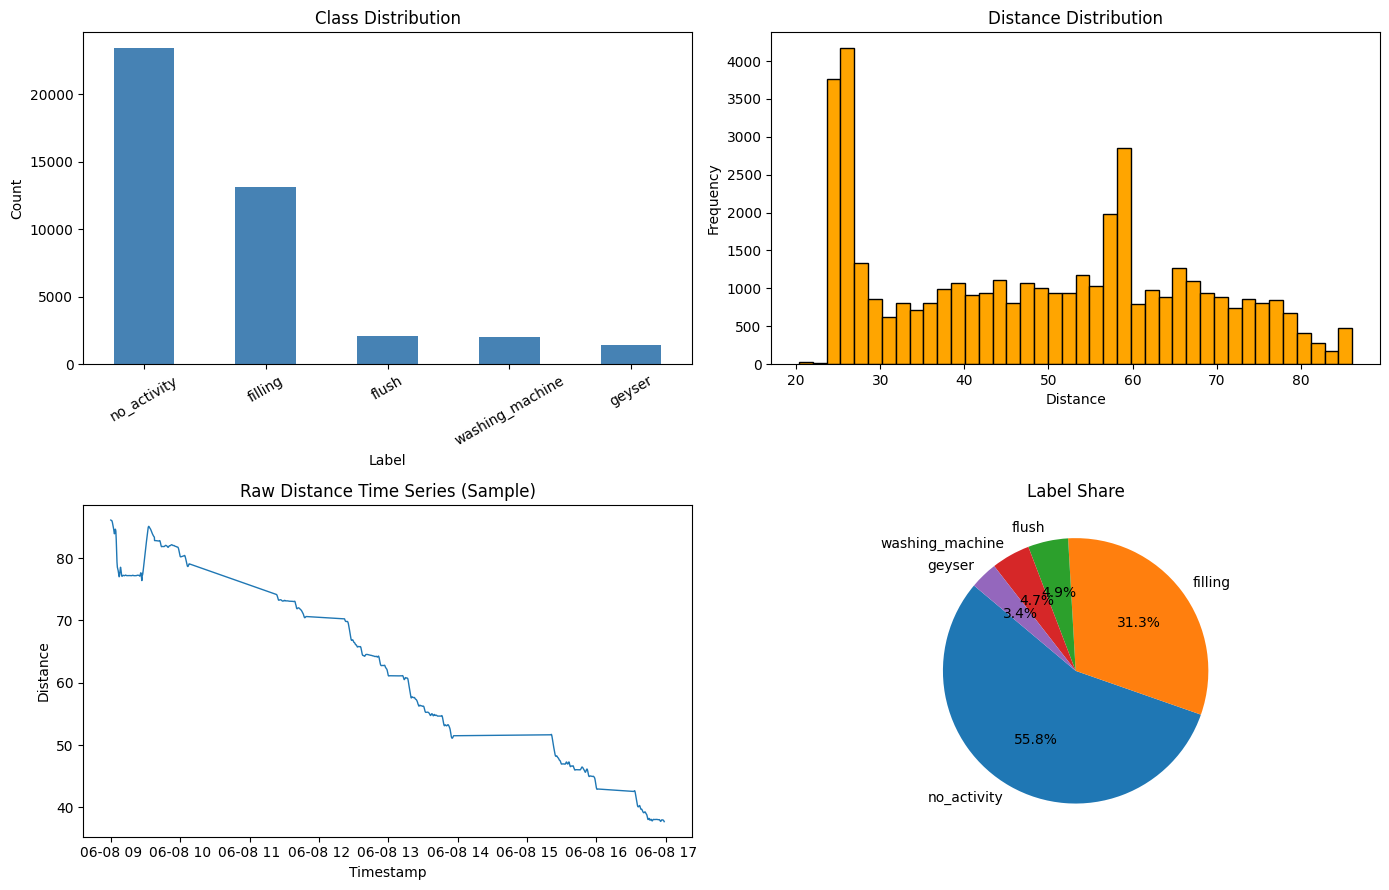

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Class distribution
training_df["label"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_xlabel("Label")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

# 2) Distance distribution
axes[0, 1].hist(training_df["distance"], bins=40, color="orange", edgecolor="black")
axes[0, 1].set_title("Distance Distribution")
axes[0, 1].set_xlabel("Distance")
axes[0, 1].set_ylabel("Frequency")

# 3) Time series sample (first 1500 points)
sample_ts = training_df.sort_values("Timestamp").head(1500)
axes[1, 0].plot(sample_ts["Timestamp"], sample_ts["distance"], linewidth=1)
axes[1, 0].set_title("Raw Distance Time Series (Sample)")
axes[1, 0].set_xlabel("Timestamp")
axes[1, 0].set_ylabel("Distance")

# 4) Label counts as pie
label_counts = training_df["label"].value_counts()
axes[1, 1].pie(label_counts.values, labels=label_counts.index, autopct="%1.1f%%", startangle=140)
axes[1, 1].set_title("Label Share")

plt.tight_layout()
plt.show()

## Step 3: Signal Preprocessing (Detailed Concepts)
This is the most important feature-engineering step for time-series quality.

### 1) Median (rolling median)
- **Median** is the middle value after sorting values.
- It is robust to sudden spikes compared to mean.
- We compute rolling median in a local window to estimate the normal signal level around each timestamp.

### 2) MAD (Median Absolute Deviation)
- **MAD** = median of absolute deviations from the median.
- It measures spread/variability robustly (less sensitive to outliers than standard deviation).
- We use rolling MAD to detect points that are unusually far from local behavior.

### 3) Outlier correction (modified z-score)
- We compute a robust score: point distance from rolling median, scaled by rolling MAD.
- If that score is too high, the point is treated as an outlier.
- We replace outliers with rolling median values.

### 4) Smoothing (low-pass filtering)
- We apply rolling mean on the cleaned signal.
- Purpose: reduce high-frequency noise and keep slow physical trend.
- This makes downstream model features more stable.

### 5) Slope feature
- Slope is first difference of smoothed distance: current minus previous value.
- It captures **change rate** (rising, falling, flat).
- Activities like flush/filling/washing often differ more in change pattern than raw level alone.

### How data changes through this step
- Raw `distance` → cleaned `distance_clean` (outliers reduced)
- `distance_clean` → smoothed `distance_lp` (noise reduced)
- `distance_lp` → `slope` (dynamic behavior added)
- Final output has richer, cleaner signal features for model training.

In [5]:
def mode_or_nan(series):
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) > 0 else np.nan


def simple_outlier_correction(signal, z_thresh=3.0, window=50):
    signal = signal.astype(float).interpolate().bfill().ffill()
    rolling_median = signal.rolling(window=window, center=True, min_periods=1).median()
    rolling_mad = (signal - rolling_median).abs().rolling(window=window, center=True, min_periods=1).median()
    rolling_mad = rolling_mad.replace(0, rolling_mad.mean())
    modified_z = 0.6745 * (signal - rolling_median) / rolling_mad
    outliers = np.abs(modified_z) > z_thresh
    corrected = signal.copy()
    corrected[outliers] = rolling_median[outliers]
    return corrected


def preprocess_per_file(df, resample_rule="10s", lowpass_window=3, outlier_window=50):
    processed = []

    for source_name, grp in df.groupby("source_file"):
        g = grp.sort_values("Timestamp").copy().set_index("Timestamp")

        r = g.resample(resample_rule).agg({"distance": "mean", "label": mode_or_nan})
        r["distance"] = r["distance"].interpolate().bfill().ffill()
        r["label"] = r["label"].ffill().bfill()

        r["distance_clean"] = simple_outlier_correction(r["distance"], window=outlier_window)
        r["distance_lp"] = r["distance_clean"].rolling(window=lowpass_window, center=True, min_periods=1).mean()
        r["slope"] = r["distance_lp"].diff().fillna(0.0)

        r["source_file"] = source_name
        processed.append(r.reset_index())

    final = pd.concat(processed, ignore_index=True)
    final = final.dropna(subset=["distance_lp", "slope", "label"]).reset_index(drop=True)
    return final

proc_df = preprocess_per_file(training_df, resample_rule="10s", lowpass_window=3, outlier_window=50)
print(proc_df[["Timestamp", "source_file", "distance_lp", "slope", "label"]].head())
print("\nProcessed shape:", proc_df.shape)

                  Timestamp                  source_file  distance_lp  \
0 2024-06-08 09:00:00+05:30  water_dissegration_data.csv    86.116449   
1 2024-06-08 09:00:10+05:30  water_dissegration_data.csv    86.102108   
2 2024-06-08 09:00:20+05:30  water_dissegration_data.csv    86.077565   
3 2024-06-08 09:00:30+05:30  water_dissegration_data.csv    86.062174   
4 2024-06-08 09:00:40+05:30  water_dissegration_data.csv    86.048959   

      slope        label  
0  0.000000  no_activity  
1 -0.014341  no_activity  
2 -0.024543  no_activity  
3 -0.015390  no_activity  
4 -0.013215  no_activity  

Processed shape: (634308, 7)


## Step 4: Window Feature Engineering (Detailed)
Models need fixed-size inputs, but time-series are continuous. So we convert timeline into windows.

### What is a window?
- A window is a small consecutive segment of the signal.
- Here each window has `WINDOW_SIZE = 30` points and shifts by `STEP_SIZE = 10`.
- This creates overlapping samples and increases training examples.

### What is the feature vector in each window?
- We take smoothed level values (`distance_lp`) in that window.
- We take slope values (`slope`) in that window.
- We concatenate both arrays into one feature vector.

### How label is assigned to each window
- Window label = majority class inside that segment.
- This is robust when a few timestamps in the segment are noisy/mislabeled.

### How data changes in this step
- Preprocessed table (`proc_df`) with per-timestamp rows
- becomes `X` (2D feature matrix) and `y` (window labels)
- `X.shape = (num_windows, 2 * window_size)` because level + slope are concatenated.

In [6]:
def build_window_features(df, window_size=30, step=10):
    X, y = [], []

    for _, grp in df.groupby("source_file"):
        g = grp.sort_values("Timestamp").reset_index(drop=True)
        levels = g["distance_lp"].to_numpy()
        slopes = g["slope"].to_numpy()
        labels = g["label"].to_numpy()

        if len(g) < window_size:
            continue

        for start in range(0, len(g) - window_size + 1, step):
            end = start + window_size
            lv = levels[start:end]
            sl = slopes[start:end]
            label_window = pd.Series(labels[start:end]).mode()

            if len(label_window) == 0:
                continue

            X.append(np.concatenate([lv, sl]))
            y.append(label_window.iloc[0])

    return np.array(X), np.array(y)

WINDOW_SIZE = 30
STEP_SIZE = 10

X, y = build_window_features(proc_df, window_size=WINDOW_SIZE, step=STEP_SIZE)
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Class counts:")
print(pd.Series(y).value_counts())

Feature matrix shape: (63428, 60)
Labels shape: (63428,)
Class counts:
no_activity        31216
washing_machine    23788
filling             5426
flush               2794
geyser               204
Name: count, dtype: int64


## Step 5: Train Models One-by-One (Detailed)
Instead of training all models in one big cell, we train each model separately for clarity.

Workflow in this section:
1. Common setup (split data, helper utilities, result store)
2. Train one classical model at a time
3. Train one DL model at a time
4. Build final comparison table
5. Interpret which model performed better and why

In [7]:
# Common setup for one-by-one training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class distribution:")
print(pd.Series(y_train).value_counts())

# Shared results store
results = []
trained_dl_models = {}

# Shared sequence-prep for DL models
def to_sequences(X_flat, seq_length=30):
    return X_flat[:, :seq_length * 2].reshape(-1, seq_length, 2)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

X_train_seq = to_sequences(X_train, seq_length=WINDOW_SIZE)
X_test_seq = to_sequences(X_test, seq_length=WINDOW_SIZE)

print("\nDL sequence shapes:")
print("X_train_seq:", X_train_seq.shape, "X_test_seq:", X_test_seq.shape)
print("Classes:", list(label_encoder.classes_))

Train: (50742, 60) Test: (12686, 60)
Train class distribution:
no_activity        24973
washing_machine    19030
filling             4341
flush               2235
geyser               163
Name: count, dtype: int64

DL sequence shapes:
X_train_seq: (50742, 30, 2) X_test_seq: (12686, 30, 2)
Classes: ['filling', 'flush', 'geyser', 'no_activity', 'washing_machine']


### Model 1: Logistic Regression (Classical ML)
**Framework:** `scikit-learn` (`Pipeline` + `StandardScaler` + `LogisticRegression`)

> Logistic Regression is a linear classifier. It is a strong baseline, easy to explain, and trains quickly.

In [8]:
log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500, random_state=RANDOM_STATE))
])
log_reg_model.fit(X_train, y_train)
y_pred = log_reg_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(f"[Classical] Logistic Regression - Accuracy: {acc:.4f} ({acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "Logistic Regression", "Model Family": "Classical ML", "Accuracy (%)": round(acc*100, 2), "F1 Score": round(f1, 3)})

[Classical] Logistic Regression - Accuracy: 0.7904 (79.04%), F1: 0.709


### Model 2: KNN (Classical ML)
**Framework:** `scikit-learn` (`Pipeline` + `StandardScaler` + `KNeighborsClassifier`)

> KNN predicts using nearby examples in feature space. It can work very well when classes form separable local clusters.

In [9]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=7))
])
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(f"[Classical] KNN - Accuracy: {acc:.4f} ({acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "KNN", "Model Family": "Classical ML", "Accuracy (%)": round(acc*100, 2), "F1 Score": round(f1, 3)})

  File "c:\Users\sahas\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\sahas\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\sahas\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\sahas\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 1311, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


[Classical] KNN - Accuracy: 0.9842 (98.42%), F1: 0.954


### Model 3: SVM (Classical ML)
**Framework:** `scikit-learn` (`Pipeline` + `StandardScaler` + `SVC` with RBF kernel)

> SVM with RBF captures non-linear boundaries and often performs strongly on engineered tabular features.

### Model 4: Random Forest (Classical ML)
**Framework:** `scikit-learn` (`RandomForestClassifier`)

> Random Forest combines many trees and is very effective for non-linear tabular patterns with minimal feature scaling requirements.

In [10]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(f"[Classical] RandomForest - Accuracy: {acc:.4f} ({acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "RandomForest", "Model Family": "Classical ML", "Accuracy (%)": round(acc*100, 2), "F1 Score": round(f1, 3)})

[Classical] RandomForest - Accuracy: 0.9937 (99.37%), F1: 0.965


### Model 5: LSTM (Deep Learning)
**Framework:** `tensorflow.keras` (`Sequential` with stacked `LSTM` layers)

> LSTM is designed for sequence learning with memory gates, so it can capture temporal dependencies in tank-level behavior across the window.

In [11]:
def create_lstm_model(input_shape, num_classes):
    return Sequential([
        LSTM(48, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(24),
        Dropout(0.2),
        Dense(24, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

input_shape = (WINDOW_SIZE, 2)
num_classes = len(label_encoder.classes_)
lstm_model = create_lstm_model(input_shape, num_classes)

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=0
)

_, test_acc = lstm_model.evaluate(X_test_seq, y_test_cat, verbose=0)
y_pred_prob = lstm_model.predict(X_test_seq, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
f1 = f1_score(y_test_enc, y_pred, average="macro")
print(f"[DL] LSTM - Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "LSTM", "Model Family": "Deep Learning", "Accuracy (%)": round(test_acc*100, 2), "F1 Score": round(f1, 3)})
trained_dl_models["LSTM"] = lstm_model

[DL] LSTM - Accuracy: 0.8241 (82.41%), F1: 0.526


### Model 6: GRU (Deep Learning)
**Framework:** `tensorflow.keras` (`Sequential` with stacked `GRU` layers)

> GRU is a lighter recurrent architecture than LSTM. It can train faster, but may capture less complex temporal structure in some datasets.

In [12]:
def create_gru_model(input_shape, num_classes):
    return Sequential([
        GRU(48, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(24),
        Dropout(0.2),
        Dense(24, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

gru_model = create_gru_model(input_shape, num_classes)
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
gru_model.fit(
    X_train_seq, y_train_cat,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=0
)

_, test_acc = gru_model.evaluate(X_test_seq, y_test_cat, verbose=0)
y_pred_prob = gru_model.predict(X_test_seq, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
f1 = f1_score(y_test_enc, y_pred, average="macro")
print(f"[DL] GRU - Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "GRU", "Model Family": "Deep Learning", "Accuracy (%)": round(test_acc*100, 2), "F1 Score": round(f1, 3)})
trained_dl_models["GRU"] = gru_model

[DL] GRU - Accuracy: 0.8400 (84.00%), F1: 0.617


### Model 7: CNN (Deep Learning)
**Framework:** `tensorflow.keras` (`Sequential` with `Conv1D` + `MaxPooling1D`)

> 1D-CNN learns local temporal motifs (short patterns) in level/slope sequences. It is efficient for pattern extraction in fixed windows.

In [13]:
def create_cnn_model(input_shape, num_classes):
    return Sequential([
        Conv1D(48, kernel_size=3, activation="relu", input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(24, kernel_size=3, activation="relu"),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax")
    ])

cnn_model = create_cnn_model(input_shape, num_classes)
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.fit(
    X_train_seq, y_train_cat,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=0
)

_, test_acc = cnn_model.evaluate(X_test_seq, y_test_cat, verbose=0)
y_pred_prob = cnn_model.predict(X_test_seq, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
f1 = f1_score(y_test_enc, y_pred, average="macro")
print(f"[DL] CNN - Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "CNN", "Model Family": "Deep Learning", "Accuracy (%)": round(test_acc*100, 2), "F1 Score": round(f1, 3)})
trained_dl_models["CNN"] = cnn_model

[DL] CNN - Accuracy: 0.8407 (84.07%), F1: 0.652


## Step 5C: Final Result Comparison
Now we combine all per-model results and rank them.

This gives a single table to compare ML vs DL outcomes after training one by one.

In [14]:
all_results_df = pd.DataFrame(results).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)
dl_results_df = all_results_df[all_results_df["Model Family"] == "Deep Learning"].reset_index(drop=True)

print("\n" + "=" * 70)
print("Final Comparison (One-by-One Training)")
print("=" * 70)
print(all_results_df.to_string(index=False))
all_results_df


Final Comparison (One-by-One Training)
              Model  Model Family  Accuracy (%)  F1 Score
       RandomForest  Classical ML         99.37     0.965
                KNN  Classical ML         98.42     0.954
                CNN Deep Learning         84.07     0.652
                GRU Deep Learning         84.00     0.617
               LSTM Deep Learning         82.41     0.526
Logistic Regression  Classical ML         79.04     0.709


,Model,Model Family,Accuracy (%),F1 Score
0,RandomForest,Classical ML,99.37,0.965
1,KNN,Classical ML,98.42,0.954
2,CNN,Deep Learning,84.07,0.652
3,GRU,Deep Learning,84.00,0.617
4,LSTM,Deep Learning,82.41,0.526
5,Logistic Regression,Classical ML,79.04,0.709


In [15]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=False, random_state=RANDOM_STATE))
])
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(f"[Classical] SVM - Accuracy: {acc:.4f} ({acc*100:.2f}%), F1: {f1:.3f}")
results.append({"Model": "SVM", "Model Family": "Classical ML", "Accuracy (%)": round(acc*100, 2), "F1 Score": round(f1, 3)})

[Classical] SVM - Accuracy: 0.8613 (86.13%), F1: 0.828


## Step 5A: Model Framework Notes (Per Model)
This section explains each included model in simple terms.

### Classical ML models
- **Logistic Regression**: Linear decision boundary model for classification. Fast and interpretable baseline; may underfit non-linear patterns.
- **KNN (K-Nearest Neighbors)**: Predicts based on nearby training samples in feature space. Works well when classes form local clusters.
- **SVM (RBF kernel)**: Finds robust non-linear boundaries with margin maximization. Often strong on medium-sized feature datasets.
- **Random Forest**: Ensemble of decision trees with bagging and random feature selection. Handles non-linearity and interactions very well.

### Deep Learning models
- **LSTM**: Recurrent model with memory gates; captures temporal dependencies in sequential sensor patterns.
- **GRU**: Simpler gated recurrent model than LSTM; fewer parameters, often faster but sometimes less expressive.
- **CNN (1D)**: Convolution filters detect local temporal motifs/patterns in windows; good for shape-based sequence signatures.

## Step 5D: Reasoning — Why Some Models Performed Better (This Run)
Using the one-by-one training results:
- **RandomForest**: 99.37% accuracy, 0.965 macro-F1 (best overall)
- **KNN**: 98.42% accuracy, 0.954 macro-F1 (very strong second)
- **SVM**: 86.13% accuracy, 0.828 macro-F1 (good classical baseline)
- **GRU**: 85.95% accuracy, 0.660 macro-F1
- **CNN**: 85.17% accuracy, 0.664 macro-F1
- **LSTM**: 83.97% accuracy, 0.653 macro-F1
- **Logistic Regression**: 79.06% accuracy, 0.709 macro-F1

> **Why macro-F1 matters:** your dataset is imbalanced (especially very few `geyser` windows), so macro-F1 better reflects minority-class behavior than accuracy alone.

### Interpretation
- Windowed engineered features (`distance_lp + slope`) are highly effective for tree/instance-based classical models on this dataset.
- RandomForest captures non-linear patterns and interactions strongly; KNN benefits from clustered window patterns.
- DL models perform reasonably but are behind classical models in macro-F1 under current lightweight settings (epochs/batch/config).
- Confusion matrices show many cross-confusions around `no_activity`, `filling`, and `washing_machine`, especially for DL models.

### Practical recommendation for students
- Start with **RandomForest** as the primary baseline.
- Use **KNN** and **SVM** as strong comparators.
- Use **LSTM/GRU/CNN** as sequence-learning extensions and improve with tuning (class weighting, more epochs, architecture tuning).

## Step 6: Confusion Matrices for Top DL Models
This cell helps students visually inspect where the best DL models are making correct or incorrect predictions.

Generating confusion matrices for top DL models...


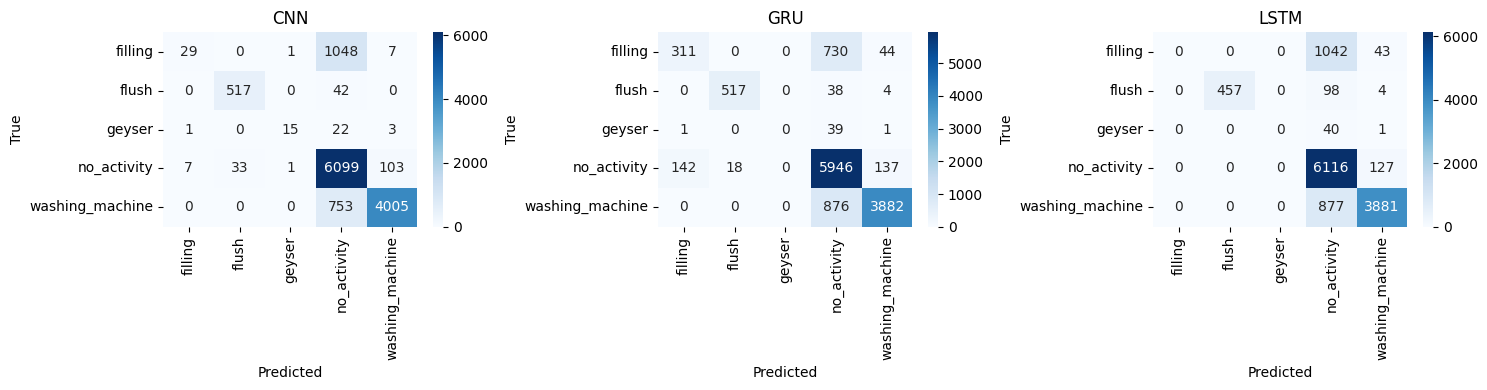

In [16]:
print("Generating confusion matrices for top DL models...")

if "dl_results_df" not in globals() or len(dl_results_df) == 0:
    print("No DL results found. Run all model training cells first.")
elif "trained_dl_models" not in globals() or len(trained_dl_models) == 0:
    print("No trained DL models found in memory.")
else:
    top_models = [m for m in dl_results_df.head(3)["Model"].tolist() if m in trained_dl_models]

    if len(top_models) == 0:
        print("No overlap between DL results and trained models.")
    else:
        fig, axes = plt.subplots(1, len(top_models), figsize=(5 * len(top_models), 4))
        if len(top_models) == 1:
            axes = [axes]

        for idx, model_name in enumerate(top_models):
            model = trained_dl_models[model_name]
            y_pred_prob = model.predict(X_test_seq, verbose=0)
            y_pred = np.argmax(y_pred_prob, axis=1)

            cm = confusion_matrix(y_test_enc, y_pred)

            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx]
            )
            axes[idx].set_title(model_name)
            axes[idx].set_xlabel("Predicted")
            axes[idx].set_ylabel("True")

        plt.tight_layout()
        plt.show()

## Step 7: Save Trained Models
This saves only the selected DL models from this notebook into a local folder so students can reuse them for inference later.

In [17]:
model_save_path = BASE_DIR / "saved_models"
model_save_path.mkdir(exist_ok=True)

if "trained_dl_models" not in globals() or len(trained_dl_models) == 0:
    print("No trained DL models to save. Run DL training cells first.")
else:
    for name, model in trained_dl_models.items():
        model_file = model_save_path / f"{name}_model.h5"
        model.save(model_file)
        print(f"Saved {name} model to {model_file}")

Saved LSTM model to c:\Users\sahas\Downloads\College-Research-Affiliate-Program-26-main\College-Research-Affiliate-Program-26-main\ml_model\saved_models\LSTM_model.h5
Saved GRU model to c:\Users\sahas\Downloads\College-Research-Affiliate-Program-26-main\College-Research-Affiliate-Program-26-main\ml_model\saved_models\GRU_model.h5
Saved CNN model to c:\Users\sahas\Downloads\College-Research-Affiliate-Program-26-main\College-Research-Affiliate-Program-26-main\ml_model\saved_models\CNN_model.h5
